In [47]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns   
import os 
import plotly.express as px
import plotly.graph_objects as go
import kagglehub
from imblearn.over_sampling import SMOTE
import os 
from sklearn.model_selection import train_test_split
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
import shap



In [48]:
# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\rafae\.cache\kagglehub\datasets\fedesoriano\stroke-prediction-dataset\versions\1


In [49]:
print (os.listdir(path))

['healthcare-dataset-stroke-data.csv']


In [50]:
arquivo = os.path.join(path, "healthcare-dataset-stroke-data.csv")

df = pd.read_csv(arquivo)
df.head()
    

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [51]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [52]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [54]:
df.isnull().sum()


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [55]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [56]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

### Tratamento das Variáveis 

In [57]:
df = df.drop(columns=["id"])

In [58]:
df["stroke"].value_counts(normalize=True)*100

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

Text(0.5, 1.0, 'Distribuição de Acidentes Vasculares Cerebrais')

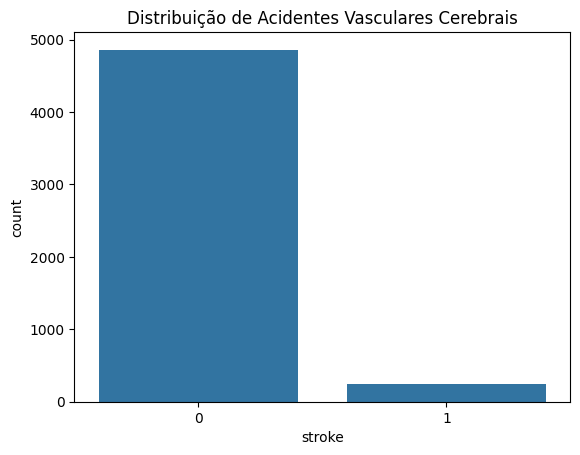

In [59]:
sns.countplot(x="stroke", data=df)
plt.title("Distribuição de Acidentes Vasculares Cerebrais")

## Idade

<Axes: xlabel='age', ylabel='Count'>

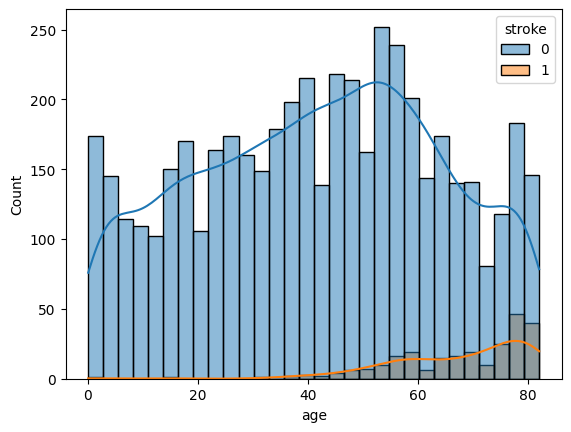

In [60]:
sns.histplot(
    data=df,
    x="age",
    hue="stroke",
    kde=True,
    bins=30
)

In [61]:
stroke_0 = df[df["stroke"] == 0]["age"]
stroke_1 = df[df["stroke"] == 1]["age"]

stat, p = mannwhitneyu(
    stroke_0,
    stroke_1,
    alternative="two-sided"
)

print("p-value:", p)

p-value: 3.726634665900011e-71


In [62]:
df.groupby("stroke")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4861.0,41.971545,22.291940,0.08,24.0,43.0,59.0,82.0
1,249.0,67.728193,12.727419,1.32,59.0,71.0,78.0,82.0


In [63]:
df["faixa_idade"] = pd.cut(
    df["age"],
    bins=[0,30,40,50,60,70,120]
)

In [64]:
pd.crosstab(
    df["faixa_idade"],
    df["stroke"],
    normalize="index"
)*100

stroke,0,1
faixa_idade,,
"(0, 30]",99.872611,0.127389
"(30, 40]",99.109792,0.890208
"(40, 50]",97.970230,2.029770
"(50, 60]",94.046173,5.953827
"(60, 70]",91.750842,8.249158
"(70, 120]",81.971831,18.028169


In [65]:
df.groupby("stroke")["avg_glucose_level"].describe()

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4861.0,104.795513,43.846069,55.12,77.12,91.47,112.83,267.76
1,249.0,132.544739,61.921056,56.11,79.79,105.22,196.71,271.74


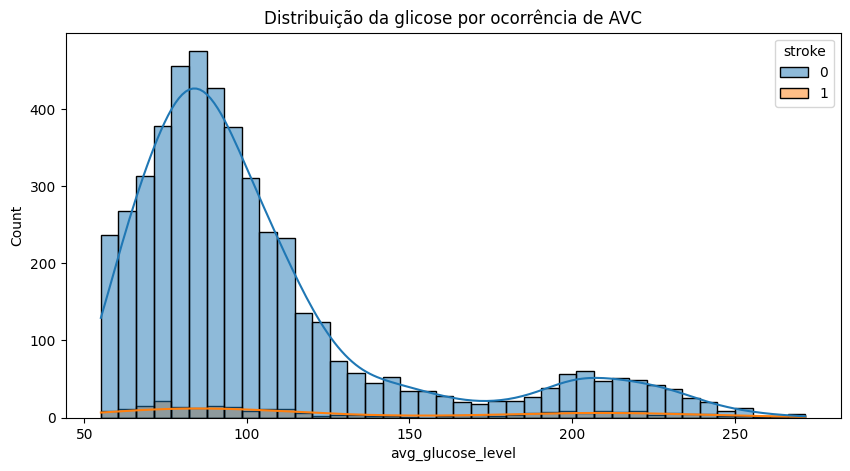

In [66]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="avg_glucose_level",
    hue="stroke",
    kde=True,
    bins=40
)

plt.title("Distribuição da glicose por ocorrência de AVC")
plt.show()

In [67]:

stroke_0_glicose = df[df["stroke"] == 0]["avg_glucose_level"]
stroke_1_glicose = df[df["stroke"] == 1]["avg_glucose_level"]

stat, p = mannwhitneyu(
    stroke_0_glicose,
    stroke_1_glicose,
    alternative="two-sided"
)

print("p-value:", p)

p-value: 3.6403672710893236e-09


In [68]:
df.groupby("stroke")["avg_glucose_level"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])

,count,mean,median,std,min,max
stroke,,,,,,
0,4861,104.795513,91.47,43.846069,55.12,267.76
1,249,132.544739,105.22,61.921056,56.11,271.74


### BMI 

In [69]:
df["bmi"].isnull().sum()

np.int64(201)

In [70]:
df.groupby("stroke")["bmi"].apply(
    lambda x: x.isnull().mean() * 100
)

stroke
0     3.312076
1    16.064257
Name: bmi, dtype: float64

In [71]:
df["bmi_missing"] = df["bmi"].isnull().astype(int)

In [72]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

In [73]:
pd.crosstab(
    df["bmi_missing"],
    df["stroke"]
)

stroke,0,1
bmi_missing,,
0,4700,209
1,161,40


In [74]:
tabela = pd.crosstab(
    df["bmi_missing"],
    df["stroke"]
)

chi2, p, dof, expected = chi2_contingency(tabela)

print("p-value:", p)

p-value: 3.107748528644105e-23


In [75]:
stroke_0_bmi = df[df["stroke"] == 0]["bmi"].dropna()
stroke_1_bmi = df[df["stroke"] == 1]["bmi"].dropna()

stat, p = mannwhitneyu(
    stroke_0_bmi,
    stroke_1_bmi,
    alternative="two-sided"
)

print("p-value:", p)

p-value: 0.0002769039186472648


In [76]:
df.groupby("stroke")["bmi"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])

,count,mean,median,std,min,max
stroke,,,,,,
0,4861,28.799115,28.1,7.777269,10.3,97.6
1,249,30.090361,28.1,5.861877,16.9,56.6


### 

## Stroke by Age, Glucose Level and BMI

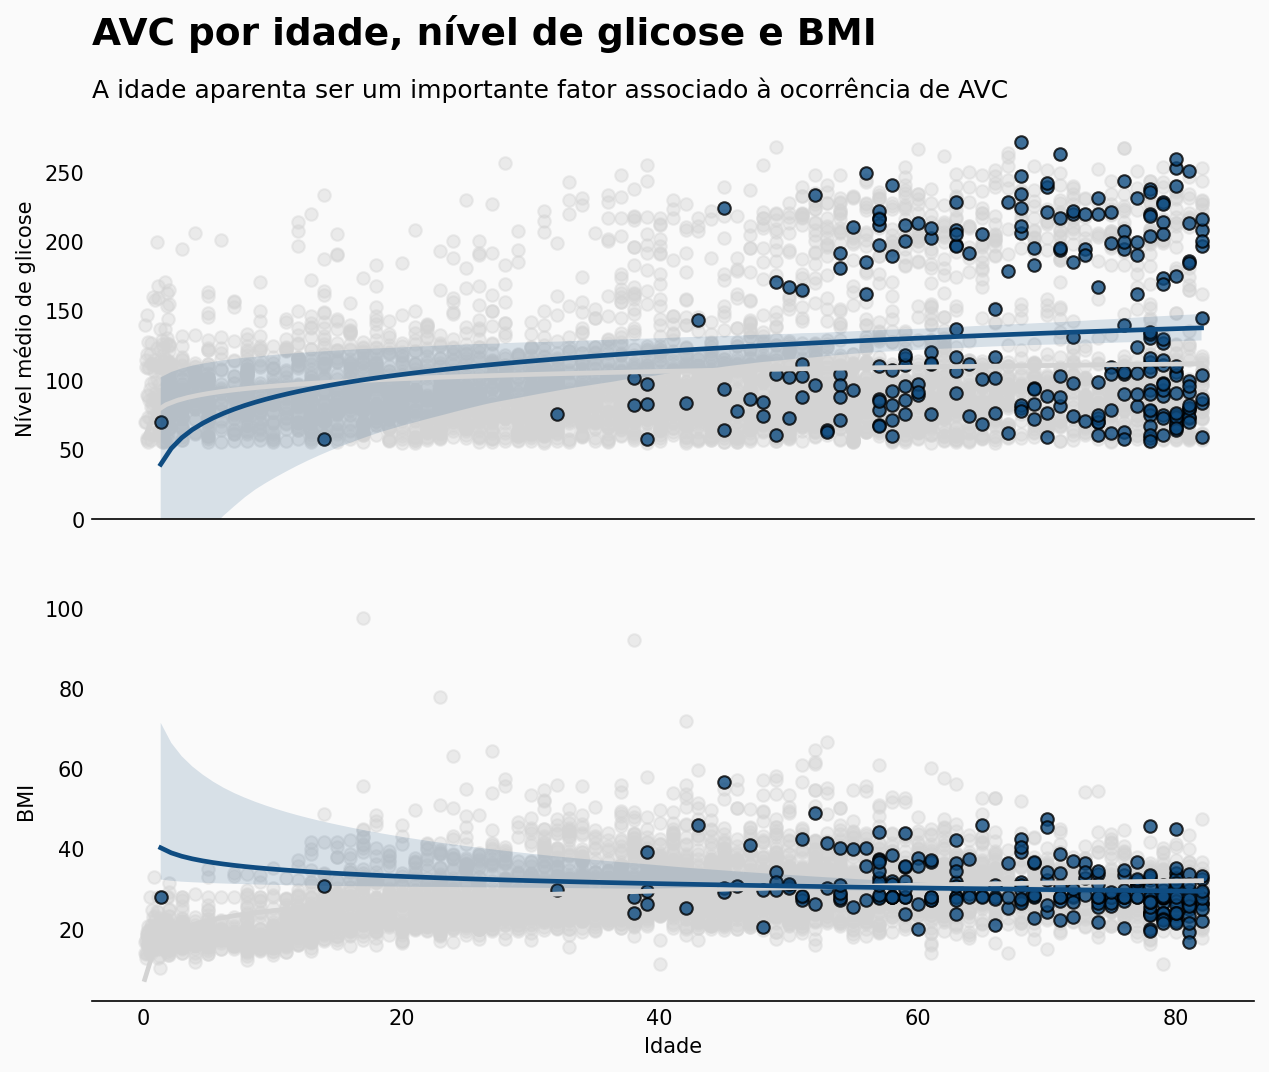

In [77]:
no_str_only = df[df["stroke"] == 0]
str_only = df[df["stroke"] == 1]

background_color = "#fafafa"

fig = plt.figure(
    figsize=(10, 16),
    dpi=150,
    facecolor=background_color
)

gs = fig.add_gridspec(4, 2)

gs.update(
    wspace=0.5,
    hspace=0.2
)

ax0 = fig.add_subplot(gs[0, 0:2])
ax1 = fig.add_subplot(gs[1, 0:2])

ax0.set_facecolor(background_color)
ax1.set_facecolor(background_color)


# ==================================================
# IDADE × GLICOSE
# ==================================================

sns.regplot(
    data=no_str_only,
    x="age",
    y="avg_glucose_level",
    color="lightgray",
    logx=True,
    scatter_kws={
        "alpha": 0.4
    },
    ax=ax0
)

sns.regplot(
    data=str_only,
    x="age",
    y="avg_glucose_level",
    color="#0f4c81",
    logx=True,
    scatter_kws={
        "edgecolor": "black",
        "alpha": 0.8
    },
    ax=ax0
)

ax0.set_ylim(0, None)

ax0.set_xlabel("")

ax0.set_ylabel(
    "Nível médio de glicose",
    fontsize=10
)

ax0.get_xaxis().set_visible(False)


# ==================================================
# IDADE × BMI
# ==================================================

sns.regplot(
    data=no_str_only,
    x="age",
    y="bmi",
    color="lightgray",
    logx=True,
    scatter_kws={
        "alpha": 0.4
    },
    ax=ax1
)

sns.regplot(
    data=str_only,
    x="age",
    y="bmi",
    color="#0f4c81",
    logx=True,
    scatter_kws={
        "edgecolor": "black",
        "alpha": 0.8
    },
    ax=ax1
)

ax1.set_xlabel(
    "Idade",
    fontsize=10
)

ax1.set_ylabel(
    "BMI",
    fontsize=10
)


# ==================================================
# FORMATAÇÃO
# ==================================================

for ax in [ax0, ax1]:

    ax.spines["top"].set_visible(False)

    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_visible(False)

    ax.tick_params(
        axis="both",
        length=0
    )


# Títulos

ax0.set_title(
    "AVC por idade, nível de glicose e BMI",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=35
)

ax0.text(
    0,
    1.05,
    "A idade aparenta ser um importante fator associado à ocorrência de AVC",
    fontsize=12,
    transform=ax0.transAxes
)

plt.show()

## Proporção acumlada de AVC por Idade

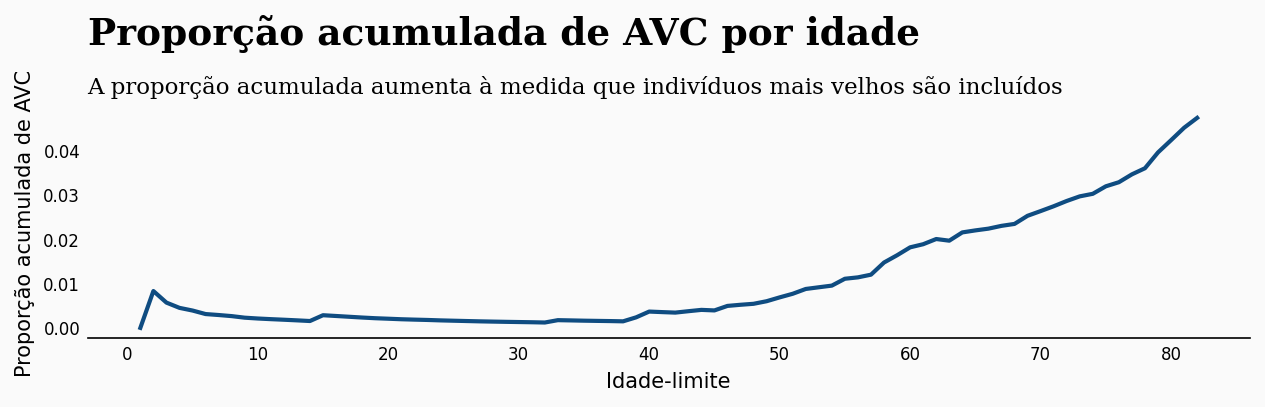

In [78]:
background_color = "#fafafa"

fig = plt.figure(
    figsize=(10, 5),
    dpi=150,
    facecolor=background_color
)

gs = fig.add_gridspec(2, 1)

gs.update(
    wspace=0.11,
    hspace=0.5
)

ax0 = fig.add_subplot(gs[0, 0])

ax0.set_facecolor(background_color)


# Listas para armazenar idade e proporção acumulada

idades = []

rate = []


# Cálculo da proporção acumulada

for idade in range(
    int(df["age"].min()) + 1,
    int(df["age"].max()) + 1
):

    grupo = df[
        df["age"] < idade
    ]

    proporcao = grupo["stroke"].mean()

    idades.append(idade)

    rate.append(proporcao)


# Gráfico

sns.lineplot(
    x=idades,
    y=rate,
    color="#0f4c81",
    linewidth=2,
    ax=ax0
)


# Remover bordas

for s in [
    "top",
    "right",
    "left"
]:

    ax0.spines[s].set_visible(False)


# Configuração dos eixos

ax0.tick_params(
    axis="both",
    which="major",
    labelsize=8
)

ax0.tick_params(
    axis="both",
    length=0
)


ax0.set_xlabel(
    "Idade-limite",
    fontsize=10
)

ax0.set_ylabel(
    "Proporção acumulada de AVC",
    fontsize=10
)


# Títulos

ax0.set_title(
    "Proporção acumulada de AVC por idade",
    fontsize=18,
    fontfamily="serif",
    fontweight="bold",
    loc="left",
    pad=30
)

ax0.text(
    0,
    1.06,
    "A proporção acumulada aumenta à medida que indivíduos mais velhos são incluídos",
    fontsize=11,
    fontfamily="serif",
    transform=ax0.transAxes
)


plt.show()

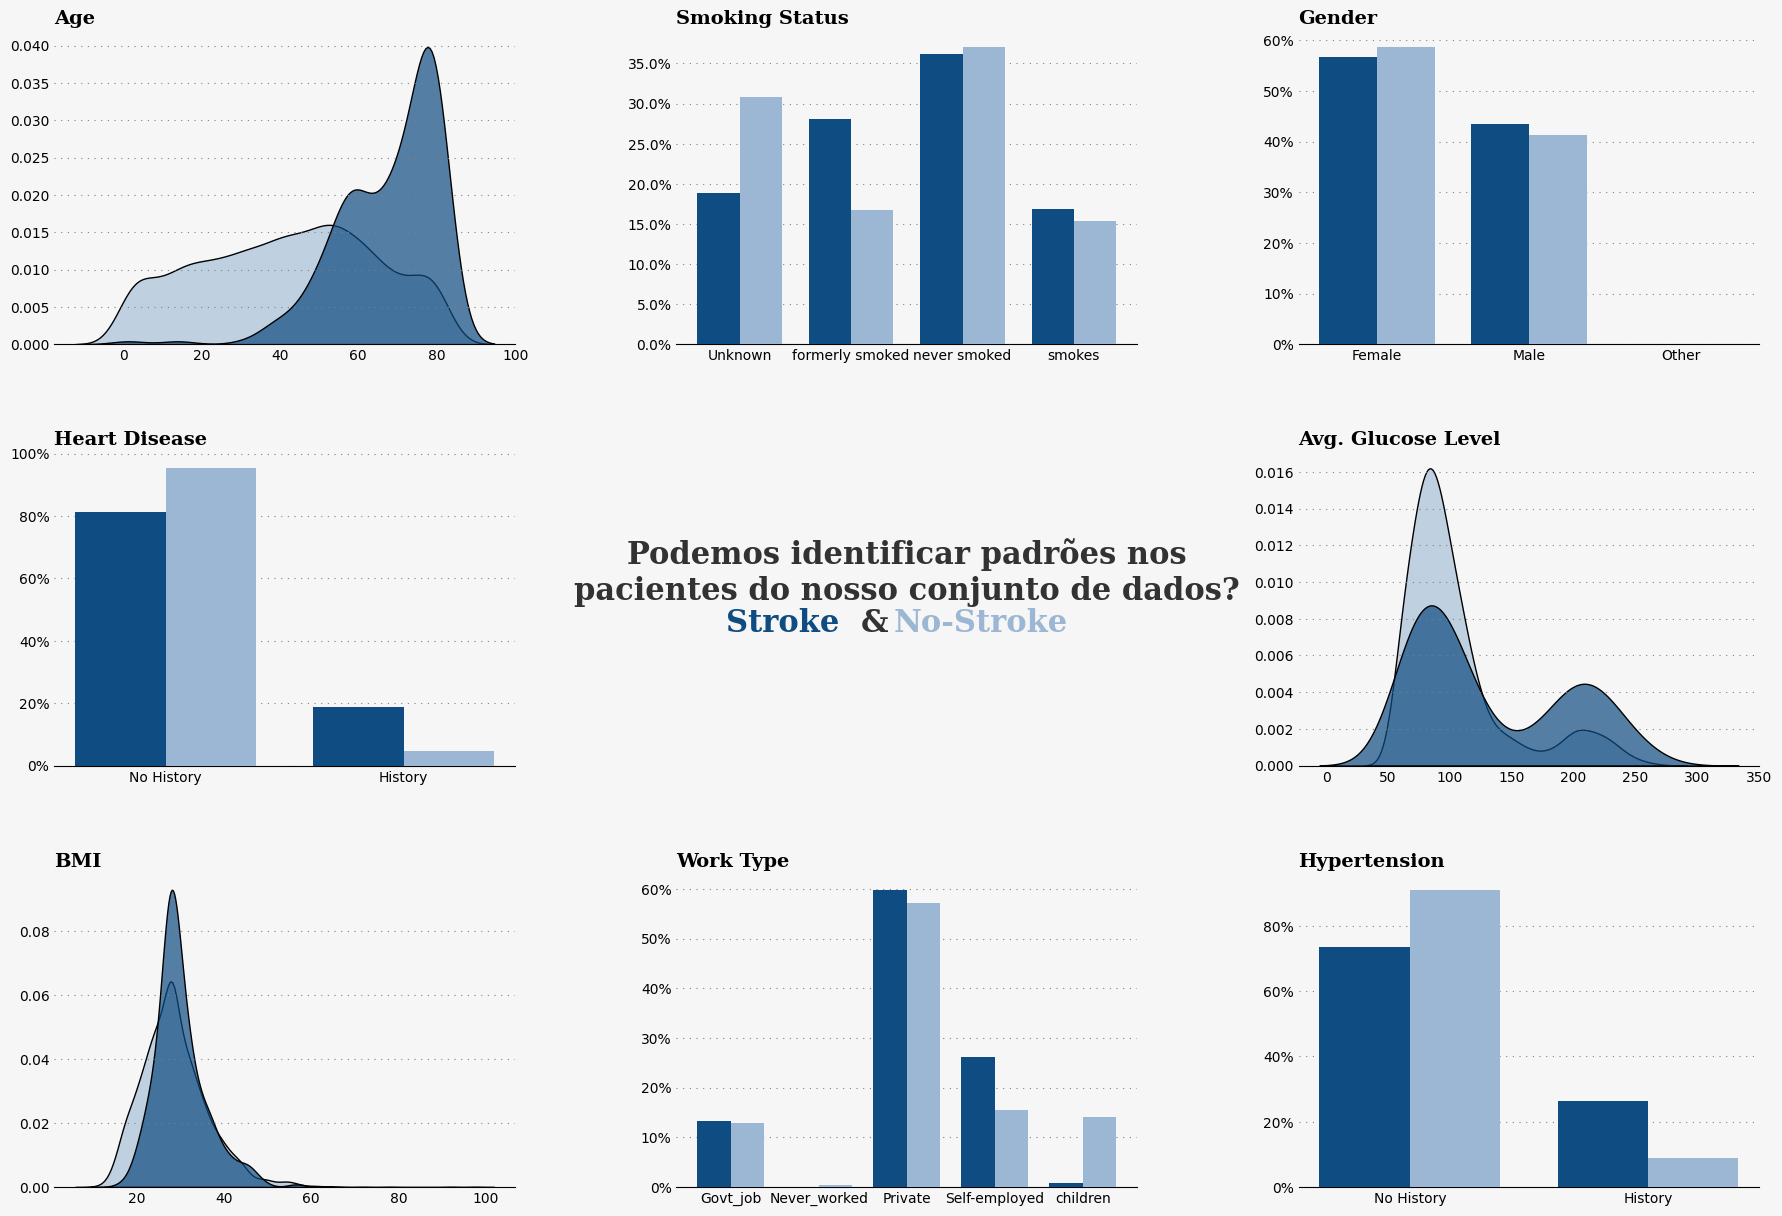

In [79]:
background_color = "#f6f6f6"
stroke_color = "#0f4c81"
no_stroke_color = "#9bb7d4"

fig = plt.figure(figsize=(22, 15), facecolor=background_color)

gs = fig.add_gridspec(3, 3)
gs.update(wspace=0.35, hspace=0.35)

axes = [fig.add_subplot(gs[i, j]) for i in range(3) for j in range(3)]

ax0, ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes


def clean_axis(ax):
    ax.set_facecolor(background_color)
    ax.grid(color="gray", linestyle=":", axis="y", zorder=0, dashes=(1, 5))
    ax.tick_params(axis="both", which="both", length=0)

    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)


def plot_kde(ax, column, title):
    sns.kdeplot(
        data=no_str_only,
        x=column,
        ax=ax,
        color=no_stroke_color,
        fill=True,
        alpha=0.6,
        edgecolor="black",
        label="No Stroke"
    )

    sns.kdeplot(
        data=str_only,
        x=column,
        ax=ax,
        color=stroke_color,
        fill=True,
        alpha=0.7,
        edgecolor="black",
        label="Stroke"
    )

    ax.set_title(title, fontsize=14, fontweight="bold", fontfamily="serif", loc="left")
    ax.set_xlabel("")
    ax.set_ylabel("")
    clean_axis(ax)


def plot_category_bar(ax, column, title, labels=None, horizontal=False):
    pos = (
        str_only[column]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    neg = (
        no_str_only[column]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    categorias = sorted(set(pos.index).union(set(neg.index)))

    pos = pos.reindex(categorias, fill_value=0)
    neg = neg.reindex(categorias, fill_value=0)

    if labels is None:
        labels = categorias

    x = np.arange(len(categorias))
    width = 0.38

    ax.bar(
        x - width / 2,
        pos.values,
        width=width,
        color=stroke_color,
        zorder=3,
        label="Stroke"
    )

    ax.bar(
        x + width / 2,
        neg.values,
        width=width,
        color=no_stroke_color,
        zorder=3,
        label="No Stroke"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

    ax.set_title(title, fontsize=14, fontweight="bold", fontfamily="serif", loc="left")
    clean_axis(ax)


# 1. Age
plot_kde(ax0, "age", "Age")

# 2. Smoking Status
plot_category_bar(ax1, "smoking_status", "Smoking Status")

# 3. Gender
plot_category_bar(ax2, "gender", "Gender")

# 4. Heart Disease
plot_category_bar(
    ax3,
    "heart_disease",
    "Heart Disease",
    labels=["No History", "History"]
)

# 5. Texto central
ax4.set_facecolor(background_color)
ax4.axis("off")

ax4.text(
    0.5,
    0.62,
    "Podemos identificar padrões nos\npacientes do nosso conjunto de dados?",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold",
    fontfamily="serif",
    color="#323232"
)

ax4.text(
    0.23,
    0.43,
    "Stroke",
    ha="center",
    fontsize=22,
    fontweight="bold",
    fontfamily="serif",
    color=stroke_color
)

ax4.text(
    0.43,
    0.43,
    "&",
    ha="center",
    fontsize=22,
    fontweight="bold",
    fontfamily="serif",
    color="#323232"
)

ax4.text(
    0.66,
    0.43,
    "No-Stroke",
    ha="center",
    fontsize=22,
    fontweight="bold",
    fontfamily="serif",
    color=no_stroke_color
)

# 6. Glucose
plot_kde(ax5, "avg_glucose_level", "Avg. Glucose Level")

# 7. BMI
plot_kde(ax6, "bmi", "BMI")

# 8. Work Type
plot_category_bar(ax7, "work_type", "Work Type")

# 9. Hypertension
plot_category_bar(
    ax8,
    "hypertension",
    "Hypertension",
    labels=["No History", "History"]
)

plt.show()

# Machine Learning 

In [80]:
df['gender'] = df['gender'].replace({'Male':0,'Female':1,'Other':-1}).astype(np.uint8)
df['Residence_type'] = df['Residence_type'].replace({'Rural':0,'Urban':1}).astype(np.uint8)
df['work_type'] = df['work_type'].replace({'Private':0,'Self-employed':1,'Govt_job':2,'children':-1,'Never_worked':-2}).astype(np.uint8)

C:\Users\rafae\AppData\Local\Temp\ipykernel_26040\2126674849.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Male':0,'Female':1,'Other':-1}).astype(np.uint8)
C:\Users\rafae\AppData\Local\Temp\ipykernel_26040\2126674849.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Residence_type'] = df['Residence_type'].replace({'Rural':0,'Urban':1}).astype(np.uint8)
C:\Users\rafae\AppData\Local\Temp\ipykernel_26040\2126674849.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated a

In [81]:
print('Inverse of Null Accuracy: ',249/(249+4861)*100)
print('Null Accuracy: ',4861/(4861+249)*100
      )

Inverse of Null Accuracy:  4.87279843444227
Null Accuracy:  95.12720156555773


In [82]:
X  = df[['gender','age','hypertension','heart_disease','work_type','avg_glucose_level','bmi']]
y = df['stroke']


X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.3, random_state=42)

In [83]:
X_test.head(2)

,gender,age,hypertension,heart_disease,work_type,avg_glucose_level,bmi
4688,0,31.0,0,0,1,64.85,23.0
4478,0,40.0,0,0,1,65.29,28.3


In [84]:
oversample = SMOTE()
X_train_resh, y_train_resh = oversample.fit_resample(X_train, y_train.ravel())

C:\Users\rafae\AppData\Local\Temp\ipykernel_26040\34031636.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  X_train_resh, y_train_resh = oversample.fit_resample(X_train, y_train.ravel())


In [85]:
print("Antes do SMOTE:")
print(y_train.value_counts())

print("\nDepois do SMOTE:")
print(pd.Series(y_train_resh).value_counts())

Antes do SMOTE:
stroke
0    1457
1      76
Name: count, dtype: int64

Depois do SMOTE:
0    1457
1    1457
Name: count, dtype: int64


In [86]:
print("Distribuição do teste:")

print(y_test.value_counts())

print("\nPercentual:")

print(
    y_test.value_counts(
        normalize=True
    ) * 100
)

Distribuição do teste:
stroke
0    3404
1     173
Name: count, dtype: int64

Percentual:
stroke
0    95.163545
1     4.836455
Name: proportion, dtype: float64
